0️⃣ Setup

In [1]:
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt

np.random.seed(42)


1️⃣ Generate synthetic OU-DFA data (ground truth)
Continuous-time OU discretization

For time step $\Delta t$
\begin{align}
f_t=e^{-\theta \Delta t} f_{t-1}+\sqrt{\frac{1-e^{-2 \theta \Delta t}}{2 \theta}} \epsilon_t
\end{align}

In [2]:
# dimensions
T = 150
n_series = 10
k_factors = 3
dt = 1.0

# OU parameters
theta_true = np.array([0.4, 0.7, 1.2])
sigma_f_true = np.array([1.0, 0.8, 0.6])

# latent factors
f_true = np.zeros((T, k_factors))
for k in range(k_factors):
    a = np.exp(-theta_true[k] * dt)
    q = sigma_f_true[k] * np.sqrt((1 - a**2) / (2 * theta_true[k]))
    for t in range(1, T):
        f_true[t, k] = a * f_true[t-1, k] + q * np.random.randn()

# sparse, identifiable loading matrix (lower triangular)
Lambda_true = np.zeros((n_series, k_factors))
Lambda_true[0, 0] = 1.2
Lambda_true[1, 0] = -0.8
Lambda_true[1, 1] = 1.0
Lambda_true[2, 1] = -1.1
Lambda_true[3, 2] = 0.9
Lambda_true[4, 2] = -0.7

# observation noise
sigma_y_true = 0.4

Y = f_true @ Lambda_true.T + np.random.normal(
    0, sigma_y_true, size=(T, n_series)
)


2️⃣ OU-DFA with sparsity and identifiability (PyMC)
Identifiability constraints

Lower triangular $\Lambda$

Positive diagonal

Ordered OU decay rates

In [4]:
with pm.Model() as ou_sparse_dfa:

    # ---------- OU parameters ----------
    theta = pm.Exponential("theta", 1.0, shape=k_factors)
    theta = pm.Deterministic("theta_ord", pt.sort(theta))

    sigma_f = pm.HalfNormal("sigma_f", 1.0, shape=k_factors)

    a = pm.Deterministic("a", pt.exp(-theta * dt))
    q = pm.Deterministic(
        "q",
        sigma_f * pt.sqrt((1 - a**2) / (2 * theta))
    )

    # ---------- Latent OU factors ----------
    f = pm.Normal("f", 0.0, 1.0, shape=(T, k_factors))

    f_ar = a * f[:-1] + q * pm.Normal("eps", 0, 1, shape=(T - 1, k_factors))
    f = pt.set_subtensor(f[1:], f_ar)

    # ---------- Sparse loadings (horseshoe) ----------
    tau = pm.HalfCauchy("tau", 1.0)
    lam = pm.HalfCauchy("lam", 1.0, shape=(n_series, k_factors))

    Lambda_raw = pm.Normal(
        "Lambda_raw",
        0.0,
        tau * lam,
        shape=(n_series, k_factors),
    )

    # ---------- Identifiability: lower triangular ----------
    Lambda_lt = pt.tril(Lambda_raw)

    # ---------- Positive diagonal ----------
    diag_idx = np.arange(k_factors)
    Lambda = pt.set_subtensor(
        Lambda_lt[diag_idx, diag_idx],
        pt.abs(Lambda_lt[diag_idx, diag_idx])
    )

    Lambda = pm.Deterministic("Lambda", Lambda)

    # ---------- Observation model ----------
    sigma_y = pm.HalfNormal("sigma_y", 1.0, shape=n_series)

    mu = pm.math.dot(f, Lambda.T)
    y = pm.Normal("y", mu=mu, sigma=sigma_y, observed=Y)

    trace = pm.sample(
        draws=1500,
        tune=1500,
        chains=4,
        target_accept=0.9,
    )


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta, sigma_f, f, eps, tau, lam, Lambda_raw, sigma_y]


Output()

Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 461 seconds.
There were 649 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


3️⃣ Diagnostics

In [5]:
az.summary(
    trace,
    var_names=["theta_ord", "sigma_f", "tau"],
    round_to=2
)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta_ord[0],0.24,0.24,0.00,0.68,0.01,0.02,544.56,392.60,1.00
theta_ord[1],0.66,0.47,0.02,1.49,0.04,0.03,180.84,381.93,1.03
theta_ord[2],1.55,0.96,0.13,3.18,0.05,0.03,300.79,1378.27,1.02
sigma_f[0],0.61,0.52,0.00,1.53,0.06,0.03,50.56,275.27,1.10
sigma_f[1],0.85,0.57,0.01,1.86,0.09,0.02,33.80,248.18,1.09
sigma_f[2],0.97,0.56,0.00,1.94,0.07,0.01,50.66,82.09,1.07
tau,0.10,0.06,0.02,0.20,0.00,0.00,290.60,809.95,1.03


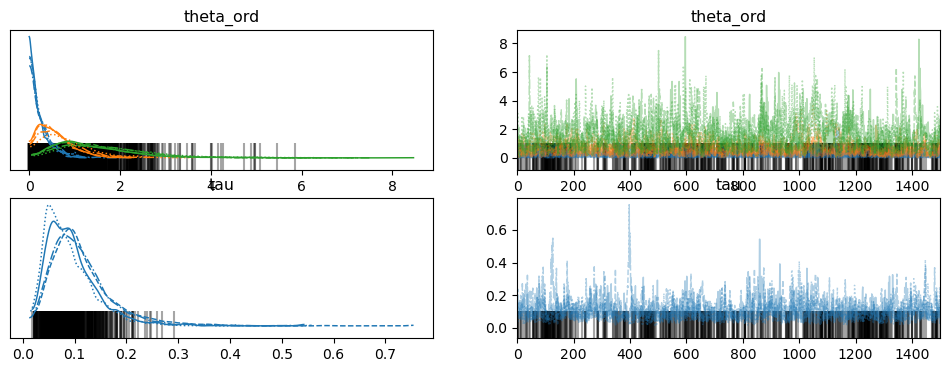

In [6]:
az.plot_trace(trace, var_names=["theta_ord", "tau"]);


4️⃣ Loadings recovery (sparsity check)

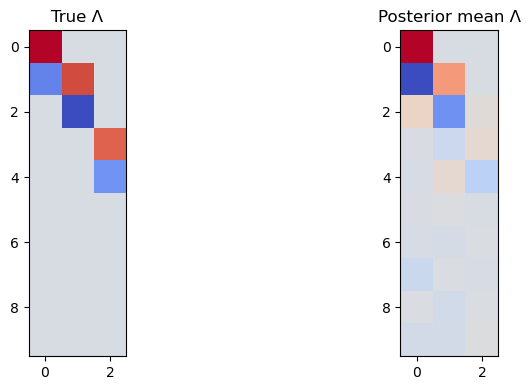

In [7]:
Lambda_post = trace.posterior["Lambda"].mean(
    dim=("chain", "draw")
).values

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(Lambda_true, cmap="coolwarm")
ax[0].set_title("True Λ")

ax[1].imshow(Lambda_post, cmap="coolwarm")
ax[1].set_title("Posterior mean Λ")

plt.tight_layout()
plt.show()


5️⃣ Latent OU factor recovery

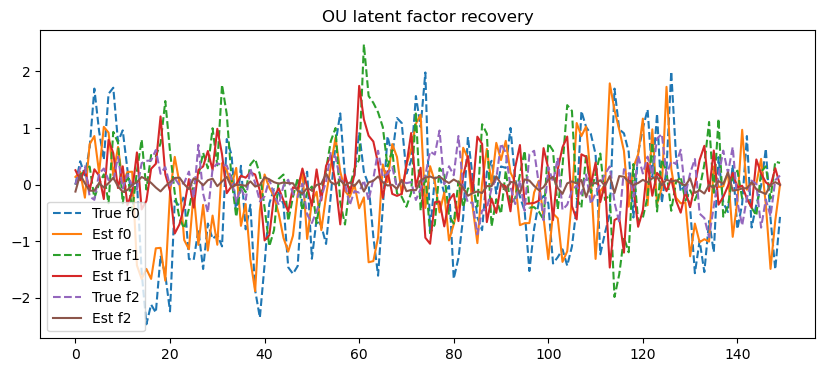

In [8]:
f_post = trace.posterior["f"].mean(
    dim=("chain", "draw")
).values

plt.figure(figsize=(10, 4))
for k in range(k_factors):
    plt.plot(f_true[:, k], "--", label=f"True f{k}")
    plt.plot(f_post[:, k], label=f"Est f{k}")
plt.legend()
plt.title("OU latent factor recovery")
plt.show()


0️⃣ Setup

In [1]:
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt

np.random.seed(42)


1️⃣ Generate synthetic irregular-time OU-DFA data
Irregular time grid

In [2]:
T = 160
time = np.cumsum(np.random.exponential(scale=1.0, size=T))
dt = np.diff(time)

n_series = 10
k_factors = 3


OU parameters

In [3]:
theta_true = np.array([0.4, 0.8, 1.3])
sigma_f_true = np.array([1.0, 0.7, 0.5])


Latent OU factors (irregular $\Delta t$)

In [4]:
f_true = np.zeros((T, k_factors))

for k in range(k_factors):
    for t in range(1, T):
        a = np.exp(-theta_true[k] * dt[t-1])
        q = sigma_f_true[k] * np.sqrt((1 - a**2) / (2 * theta_true[k]))
        f_true[t, k] = a * f_true[t-1, k] + q * np.random.randn()


Identifiable sparse loadings

In [5]:
Lambda_true = np.zeros((n_series, k_factors))
Lambda_true[0, 0] = 1.2
Lambda_true[1, 0] = -0.8
Lambda_true[1, 1] = 1.0
Lambda_true[2, 1] = -1.1
Lambda_true[3, 2] = 0.9
Lambda_true[4, 2] = -0.7


Observations

In [6]:
sigma_y_true = 0.4
Y = f_true @ Lambda_true.T + np.random.normal(
    0, sigma_y_true, size=(T, n_series)
)


2️⃣ Irregular-time OU-DFA model (PyMC)
Key changes vs regular-time

Each transition uses its own $dt[t]$

OU transition matrices are time-varying

Identifiability preserved

In [7]:
with pm.Model() as irregular_ou_dfa:
    dt_shared = pm.Data("dt", dt)

    # ---------- OU parameters ----------
    theta = pm.Exponential("theta", 1.0, shape=k_factors)
    theta = pm.Deterministic("theta_ord", pt.sort(theta))

    sigma_f = pm.HalfNormal("sigma_f", 1.0, shape=k_factors)

    # time-varying OU coefficients
    a = pm.Deterministic(
        "a",
        pt.exp(-theta * dt_shared[:, None])
    )

    q = pm.Deterministic(
        "q",
        sigma_f
        * pt.sqrt((1 - a**2) / (2 * theta))
    )

    # ---------- Latent factors ----------
    f0 = pm.Normal("f0", 0.0, 1.0, shape=k_factors)

    eps = pm.Normal("eps", 0.0, 1.0, shape=(T - 1, k_factors))

    f_rest = a * f0 + q * eps
    f = pt.concatenate([[f0], pt.cumsum(f_rest, axis=0)])

    f = pm.Deterministic("f", f)

    # ---------- Sparse loadings ----------
    tau = pm.HalfCauchy("tau", 1.0)
    lam = pm.HalfCauchy("lam", 1.0, shape=(n_series, k_factors))

    Lambda_raw = pm.Normal(
        "Lambda_raw",
        0.0,
        tau * lam,
        shape=(n_series, k_factors),
    )

    # ---------- Identifiability ----------
    Lambda_lt = pt.tril(Lambda_raw)

    diag_idx = np.arange(k_factors)
    Lambda = pt.set_subtensor(
        Lambda_lt[diag_idx, diag_idx],
        pt.abs(Lambda_lt[diag_idx, diag_idx])
    )

    Lambda = pm.Deterministic("Lambda", Lambda)

    # ---------- Observation model ----------
    sigma_y = pm.HalfNormal("sigma_y", 1.0, shape=n_series)

    mu = pm.math.dot(f, Lambda.T)
    y = pm.Normal("y", mu=mu, sigma=sigma_y, observed=Y)

    trace = pm.sample(
        draws=1500,
        tune=1500,
        chains=4,
        target_accept=0.9,
    )


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta, sigma_f, f0, eps, tau, lam, Lambda_raw, sigma_y]


Output()

/u/zwu1/.conda/envs/gnpc/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/u/zwu1/.conda/envs/gnpc/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/u/zwu1/.conda/envs/gnpc/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/u/zwu1/.conda/envs/gnpc/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 775 seconds.
There were 541 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


3️⃣ Posterior predictive sampling

In [ ]:
with irregular_ou_dfa:
    ppc = pm.sample_posterior_predictive(
        trace,
        var_names=["y"],
        random_seed=42
    )


Convert to ArviZ:

In [ ]:
idata = az.from_pymc(
    trace=trace,
    posterior_predictive=ppc,
    observed_data={"y": Y}
)


4️⃣ Posterior Predictive Checks (PPCs)
4.1 Marginal distribution check

In [ ]:
az.plot_ppc(
    idata,
    data_pairs={"y": "y"},
    num_pp_samples=100
)
plt.show()


4.2 Time-series PPC (selected variables)

In [ ]:
series_idx = [0, 1, 3]

y_pp = idata.posterior_predictive["y"].mean(
    dim=("chain", "draw")
).values

plt.figure(figsize=(10, 4))
for i in series_idx:
    plt.plot(time, Y[:, i], "k-", label=f"obs y{i}" if i == 0 else None)
    plt.plot(time, y_pp[:, i], "--", label=f"pp mean y{i}")
plt.legend()
plt.title("Posterior predictive mean vs observed")
plt.show()


4.3 Residual autocorrelation check

In [ ]:
resid = Y - y_pp

plt.figure(figsize=(8, 4))
for i in series_idx:
    plt.acorr(resid[:, i], maxlags=30, alpha=0.2)
plt.title("Residual autocorrelation (should be small)")
plt.show()


5️⃣ Latent OU factor recovery

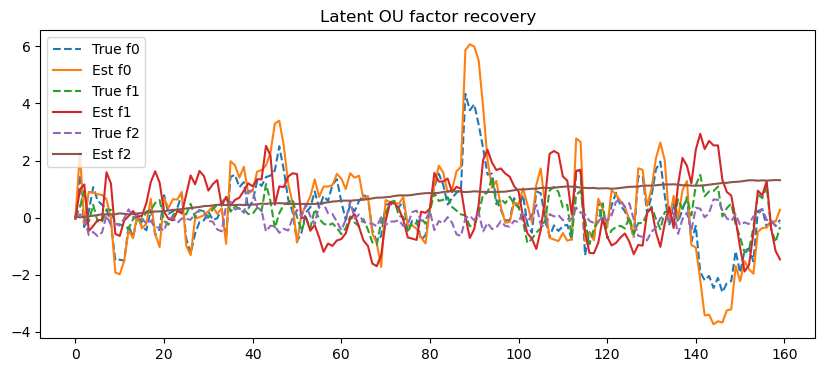

In [8]:
f_post = trace.posterior["f"].mean(
    dim=("chain", "draw")
).values

plt.figure(figsize=(10, 4))
for k in range(k_factors):
    plt.plot(f_true[:, k], "--", label=f"True f{k}")
    plt.plot(f_post[:, k], label=f"Est f{k}")
plt.legend()
plt.title("Latent OU factor recovery")
plt.show()